# Week 2 - Day 7

# Advanced Exploratory Data Analysis (EDA)

## IBM HR Analytics Employee Attrition Dataset

### Objective

The objective of this task is to perform a comprehensive Exploratory Data Analysis (EDA) on the IBM HR Analytics Employee Attrition dataset. The analysis includes dataset inspection, missing value analysis, outlier detection, distribution analysis, target variable analysis, and correlation analysis to identify meaningful patterns and insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Dataset Overview

In this section, we examine the basic structure of the dataset including:

- Number of rows and columns
- Data types
- Column information
- Statistical summary

This helps understand the overall dataset before analysis.

In [2]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Missing Value Analysis

Missing values can negatively impact data analysis and machine learning models.

In this section:

- Missing values are identified.
- Missing value percentages are calculated.
- Dataset quality is evaluated.

In [3]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by='Missing Values',
    ascending=False
)

,Missing Values,Percentage
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


# Missing Value Findings

### Observations

- The dataset contains very few or no missing values.
- Data quality appears good.
- No major data cleaning is required.

# Outlier Detection

Outliers are extreme values that differ significantly from other observations.

The IQR (Interquartile Range) method and boxplots are used to identify outliers in Monthly Income.

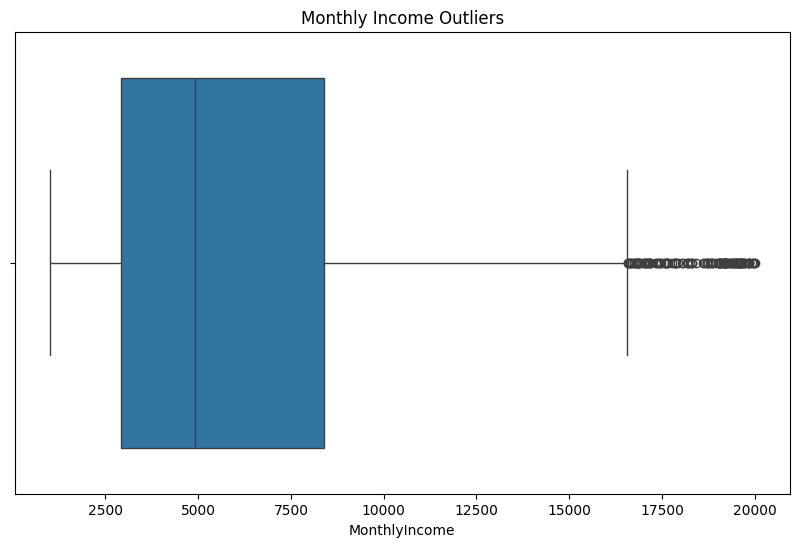

In [4]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['MonthlyIncome'])

plt.title('Monthly Income Outliers')

plt.show()

In [5]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['MonthlyIncome'] < lower_bound) |
    (df['MonthlyIncome'] > upper_bound)
]

print("Total Outliers:", len(outliers))

Total Outliers: 114


# Outlier Analysis Findings

### Observations

- Monthly Income contains several outliers.
- These values may represent highly paid employees.
- Outliers should be investigated before removal.

# Distribution Analysis

Understanding data distributions helps identify:

- Skewness
- Data spread
- Normality
- Potential transformations

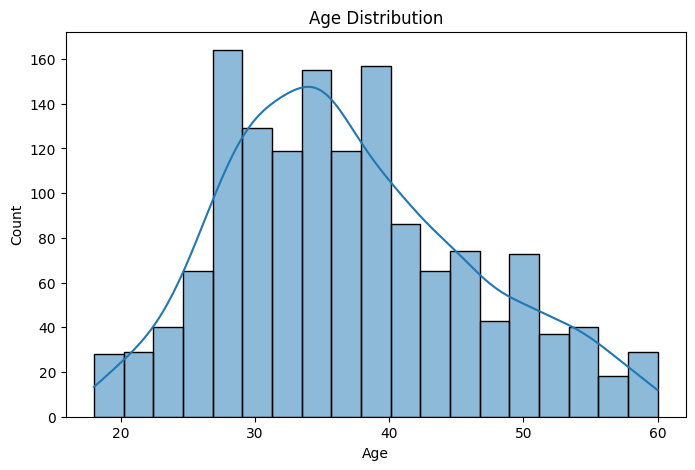

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    kde=True
)

plt.title("Age Distribution")

plt.show()

### Age Distribution Findings

- Most employees belong to middle-age groups.
- The distribution appears approximately normal.
- Very young and very old employees are fewer in number.

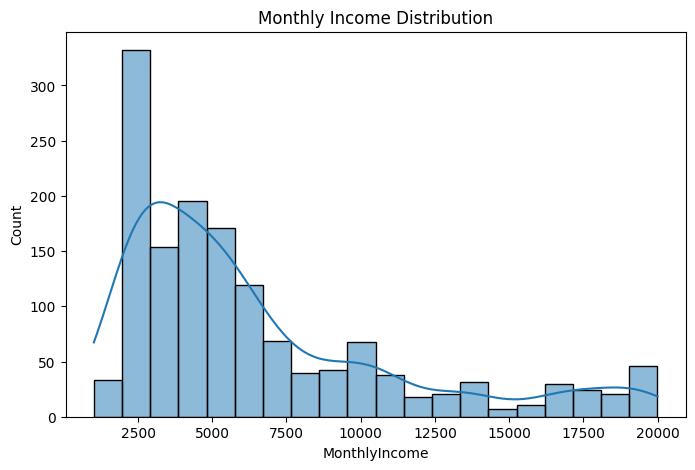

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyIncome'],
    kde=True
)

plt.title("Monthly Income Distribution")

plt.show()

### Monthly Income Distribution Findings

- Monthly Income is right-skewed.
- Most employees earn moderate salaries.
- A small number of employees earn significantly higher salaries.

# Target Variable Analysis

The target variable is Attrition.

This section evaluates:

- Employee retention
- Employee attrition
- Class balance

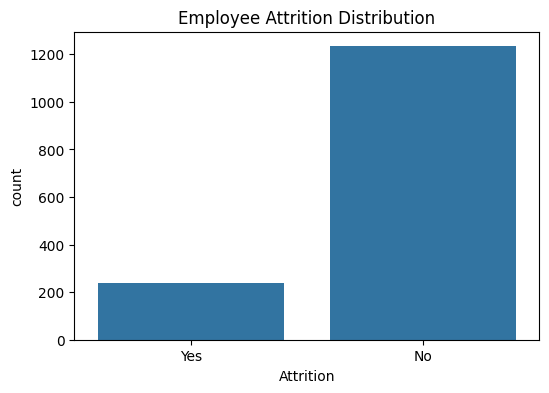

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Attrition',
    data=df
)

plt.title('Employee Attrition Distribution')

plt.show()

### Attrition Analysis Findings

- Most employees stayed with the company.
- Employee attrition is lower than retention.
- The dataset shows some class imbalance.

# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

A heatmap is used to visualize correlations among employee features.

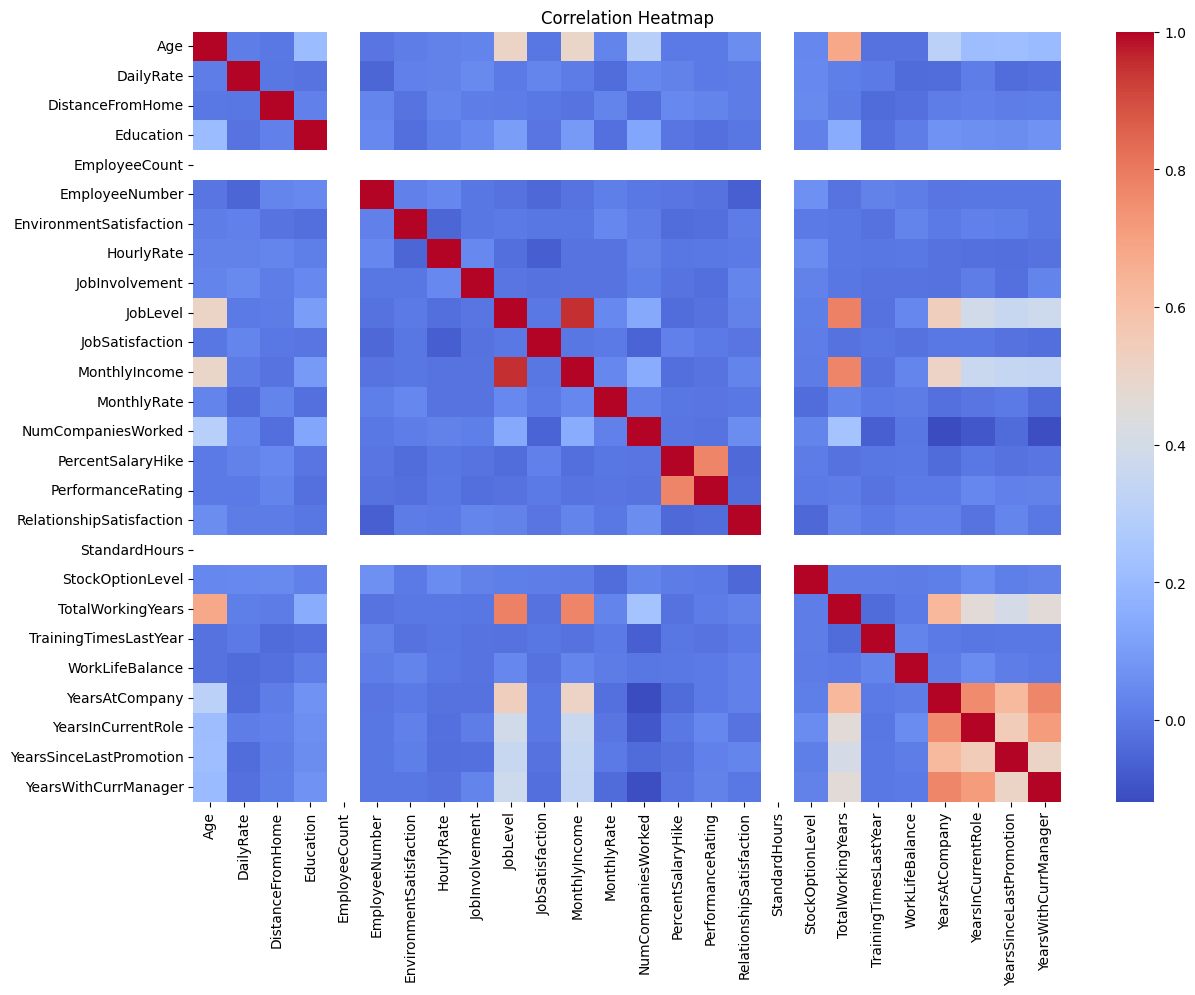

In [9]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# Correlation Findings

### Observations

- Some numerical variables show moderate positive correlations.
- Strong correlations may indicate important predictors.
- Correlation analysis assists in future feature selection.

# Conclusion

## Key Findings

- The dataset contains minimal missing values.
- Monthly Income contains several outliers.
- Most employees belong to middle-age groups.
- Employee retention is significantly higher than attrition.
- Correlation analysis revealed relationships among numerical variables.

## Learning Outcomes

By completing this task, I learned how to:

- Perform advanced EDA.
- Analyze missing values.
- Detect outliers using IQR and boxplots.
- Study feature distributions.
- Analyze target variables.
- Interpret correlation heatmaps.
- Extract meaningful business insights from data.